In [17]:
from pathlib import Path
import rasterio
from rasterio.enums import Resampling
import numpy as np
import matplotlib.pyplot as plt
import random
import shutil

In [7]:
INPUT_DIR = Path("CTGAN")
OUTPUT_DIR = Path("CTGAN_resized")
TARGET_SIZE = 32  # change to 16 or 8 if needed

In [8]:
def resize_geotiff(src_path: Path, dst_path: Path, target_size: int):
    with rasterio.open(src_path) as src:
        data = src.read(
            out_shape=(src.count, target_size, target_size),
            resampling=Resampling.bilinear
        )

        scale_x = src.width / target_size
        scale_y = src.height / target_size
        new_transform = src.transform * src.transform.scale(scale_x, scale_y)

        profile = src.profile.copy()
        profile.update({
            "height": target_size,
            "width": target_size,
            "transform": new_transform,
            "count": src.count,
            "crs": src.crs,
            "dtype": data.dtype,
        })

        dst_path.parent.mkdir(parents=True, exist_ok=True)

        with rasterio.open(dst_path, "w", **profile) as dst:
            dst.write(data)

            if src.descriptions:
                dst.descriptions = src.descriptions

            if src.colorinterp:
                dst.colorinterp = src.colorinterp

            if src.units:
                dst._set_all_units(list(src.units))

            if src.nodatavals and any(v is not None for v in src.nodatavals):
                nodata_val = src.nodatavals[0]
                if nodata_val is not None:
                    dst.nodata = nodata_val

            dst.update_tags(**src.tags())

            for b in range(1, src.count + 1):
                dst.update_tags(b, **src.tags(b))

In [9]:
def process_dataset(input_dir: Path, output_dir: Path, target_size: int):
    tif_files = list(input_dir.rglob("*.tif")) + list(input_dir.rglob("*.tiff"))
    print(f"Found {len(tif_files)} TIFF files")

    for i, tif_path in enumerate(tif_files, 1):
        rel = tif_path.relative_to(input_dir)
        out_path = output_dir / rel

        try:
            resize_geotiff(tif_path, out_path, target_size)
            print(f"[{i}/{len(tif_files)}] Done: {rel}")
        except Exception as e:
            print(f"[{i}/{len(tif_files)}] Failed: {rel} -> {e}")

In [10]:
def prepare_rgb(arr):
    if arr.ndim == 3:
        rgb = arr[:3].astype(np.float32)
        rgb = np.transpose(rgb, (1, 2, 0))
    elif arr.ndim == 2:
        rgb = arr.astype(np.float32)
    else:
        raise ValueError(f"Unsupported array shape for visualization: {arr.shape}")

    rgb = np.nan_to_num(rgb)

    upper = np.percentile(rgb, 98) if np.max(rgb) > 0 else 1
    rgb = np.clip(rgb, 0, upper)

    rgb = rgb - rgb.min()
    if rgb.max() > 0:
        rgb = rgb / rgb.max()

    return rgb

In [11]:
def show_random_before_after(input_dir, output_dir, n=4):
    input_files = list(input_dir.rglob("*.tif")) + list(input_dir.rglob("*.tiff"))

    if len(input_files) == 0:
        print("No TIFF files found.")
        return

    samples = random.sample(input_files, min(n, len(input_files)))

    fig, axes = plt.subplots(len(samples), 2, figsize=(10, 4 * len(samples)))

    if len(samples) == 1:
        axes = np.array([axes])

    for row, in_file in enumerate(samples):
        rel = in_file.relative_to(input_dir)
        out_file = output_dir / rel

        with rasterio.open(in_file) as src_before:
            before = src_before.read()

        with rasterio.open(out_file) as src_after:
            after = src_after.read()

        before_rgb = prepare_rgb(before)
        after_rgb = prepare_rgb(after)

        axes[row, 0].imshow(before_rgb, cmap="gray" if before_rgb.ndim == 2 else None)
        axes[row, 0].set_title(f"Before: {rel}")
        axes[row, 0].axis("off")

        axes[row, 1].imshow(after_rgb, cmap="gray" if after_rgb.ndim == 2 else None)
        axes[row, 1].set_title(f"After: {rel}")
        axes[row, 1].axis("off")

    plt.tight_layout()
    plt.show()

In [12]:
process_dataset(INPUT_DIR, OUTPUT_DIR, TARGET_SIZE)

Found 13669 TIFF files
[1/13669] Done: CTGAN/Sen2_MTC/dataset/Sen2_MTC/T37TGN_R078/cloud/T37TGN_R078_43_0.tif
[2/13669] Done: CTGAN/Sen2_MTC/dataset/Sen2_MTC/T37TGN_R078/cloud/T37TGN_R078_41_2.tif
[3/13669] Done: CTGAN/Sen2_MTC/dataset/Sen2_MTC/T37TGN_R078/cloud/T37TGN_R078_22_1.tif
[4/13669] Done: CTGAN/Sen2_MTC/dataset/Sen2_MTC/T37TGN_R078/cloud/T37TGN_R078_67_1.tif
[5/13669] Done: CTGAN/Sen2_MTC/dataset/Sen2_MTC/T37TGN_R078/cloud/T37TGN_R078_5_1.tif
[6/13669] Done: CTGAN/Sen2_MTC/dataset/Sen2_MTC/T37TGN_R078/cloud/T37TGN_R078_39_2.tif
[7/13669] Done: CTGAN/Sen2_MTC/dataset/Sen2_MTC/T37TGN_R078/cloud/T37TGN_R078_58_2.tif
[8/13669] Done: CTGAN/Sen2_MTC/dataset/Sen2_MTC/T37TGN_R078/cloud/T37TGN_R078_5_0.tif
[9/13669] Done: CTGAN/Sen2_MTC/dataset/Sen2_MTC/T37TGN_R078/cloud/T37TGN_R078_22_0.tif
[10/13669] Done: CTGAN/Sen2_MTC/dataset/Sen2_MTC/T37TGN_R078/cloud/T37TGN_R078_67_0.tif
[11/13669] Done: CTGAN/Sen2_MTC/dataset/Sen2_MTC/T37TGN_R078/cloud/T37TGN_R078_7_2.tif
[12/13669] Done: CTGA

/Users/dsarkar/miniconda3/envs/Desktop/lib/python3.13/site-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


[72/13669] Done: CTGAN/Sen2_MTC/dataset/Sen2_MTC/T37TGN_R078/cloud/T37TGN_R078_38_0.tif
[73/13669] Done: CTGAN/Sen2_MTC/dataset/Sen2_MTC/T37TGN_R078/cloud/T37TGN_R078_59_1.tif
[74/13669] Done: CTGAN/Sen2_MTC/dataset/Sen2_MTC/T37TGN_R078/cloud/T37TGN_R078_38_2.tif
[75/13669] Done: CTGAN/Sen2_MTC/dataset/Sen2_MTC/T37TGN_R078/cloud/T37TGN_R078_40_2.tif
[76/13669] Done: CTGAN/Sen2_MTC/dataset/Sen2_MTC/T37TGN_R078/cloud/T37TGN_R078_66_1.tif
[77/13669] Done: CTGAN/Sen2_MTC/dataset/Sen2_MTC/T37TGN_R078/cloud/T37TGN_R078_23_1.tif
[78/13669] Done: CTGAN/Sen2_MTC/dataset/Sen2_MTC/T37TGN_R078/cloud/T37TGN_R078_4_1.tif
[79/13669] Done: CTGAN/Sen2_MTC/dataset/Sen2_MTC/T37TGN_R078/cloud/T37TGN_R078_42_0.tif
[80/13669] Done: CTGAN/Sen2_MTC/dataset/Sen2_MTC/T37TGN_R078/cloud/T37TGN_R078_6_2.tif
[81/13669] Done: CTGAN/Sen2_MTC/dataset/Sen2_MTC/T37TGN_R078/cloud/T37TGN_R078_21_2.tif
[82/13669] Done: CTGAN/Sen2_MTC/dataset/Sen2_MTC/T37TGN_R078/cloud/T37TGN_R078_64_2.tif
[83/13669] Done: CTGAN/Sen2_MTC/da

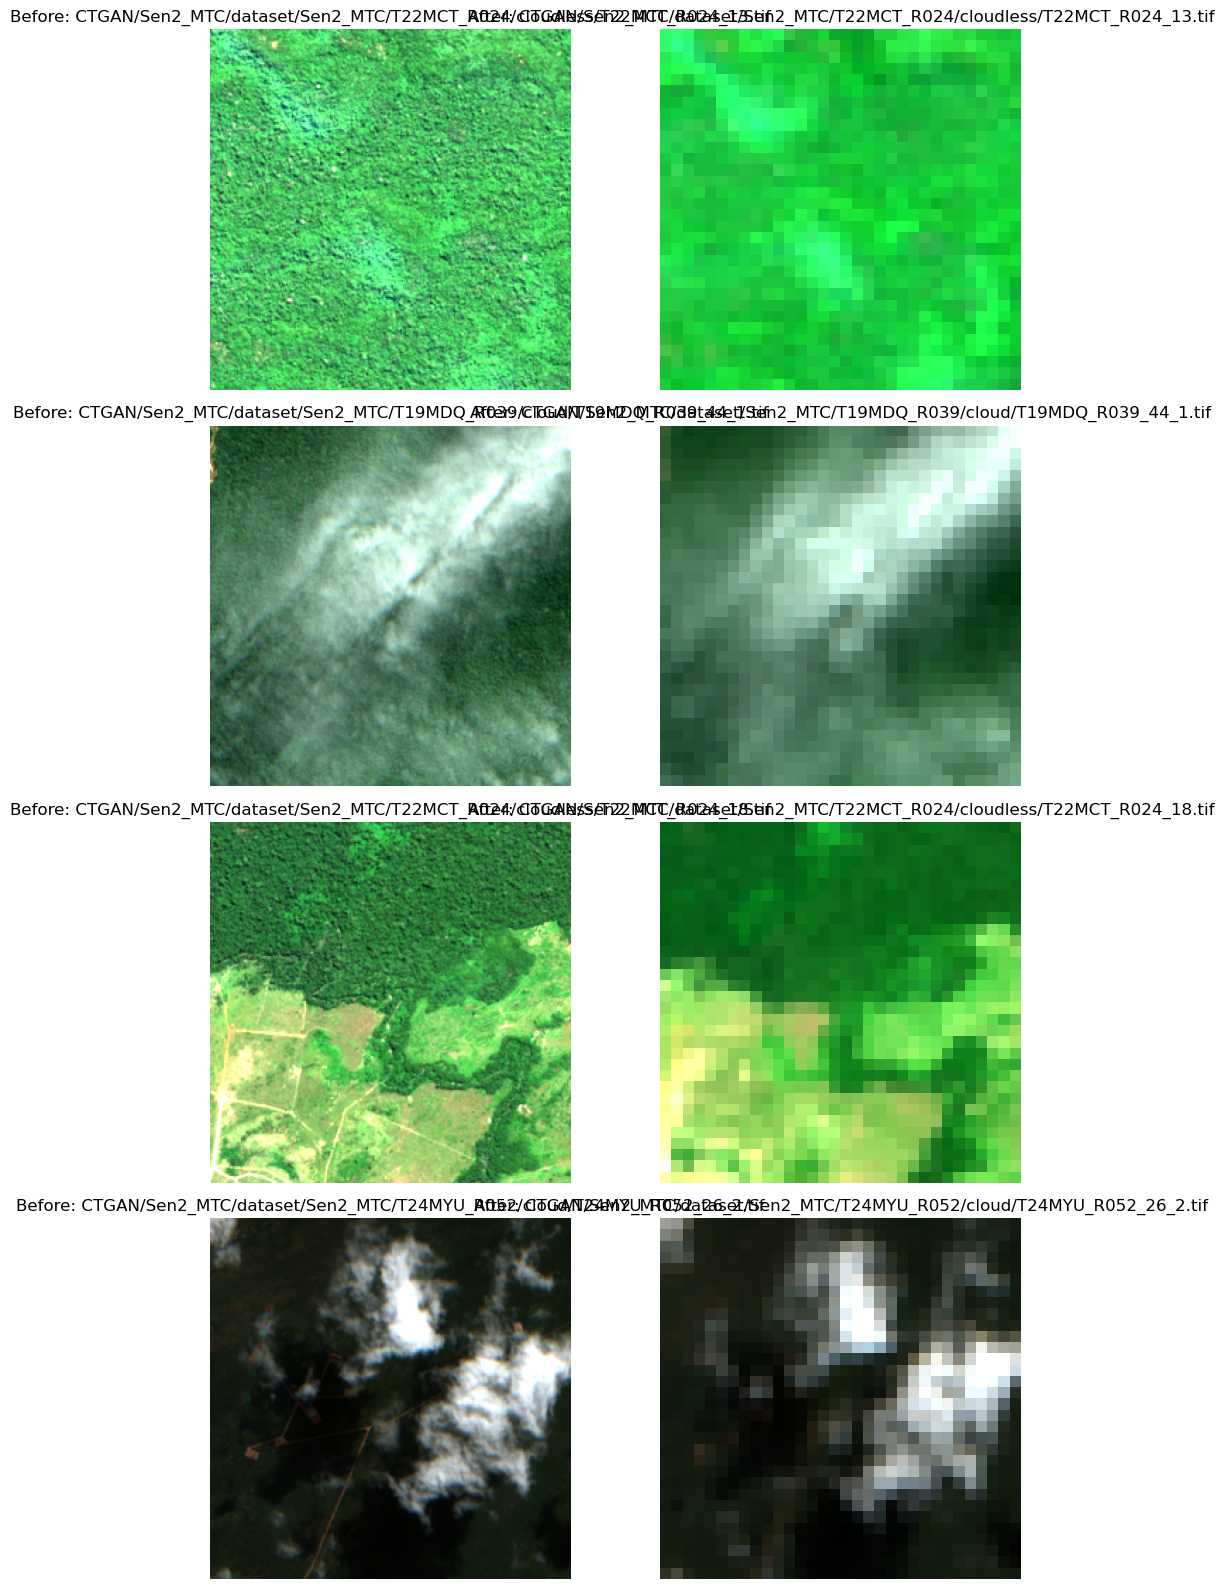

In [16]:
show_random_before_after(INPUT_DIR, OUTPUT_DIR, n=4)